# 🎬 한국어 영화 리뷰 감성 분석

**실행 환경**: Google Colab / Python 3.10  
**평가 기준**: MCC (Matthews Correlation Coefficient)  
**목표**: 영화 리뷰 텍스트를 `POSITIVE` / `NEGATIVE` 로 이진 분류

---
### 📋 노트북 구성
1. 환경 설정 (패키지 설치 + import)
2. 데이터 탐색 (EDA)
3. 텍스트 전처리 & 벡터화
4. 모델 학습 및 비교
5. 검증 및 평가
6. 하이퍼파라미터 튜닝
7. 테스트 예측 + CSV 생성
8. 결론

## 1. 🔧 환경 설정

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 패키지 설치 (Colab / Kaggle 환경에서 실행)
# Okt는 KoNLPy에 포함 — Java/JPype 필요 (Colab은 기본 설치됨)
!pip install konlpy koreanize-matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.0/438.0 kB 21.5 MB/s eta 0:00:00


In [3]:
# ── 기본 라이브러리 ──────────────────────────────────────────
import re
import numpy as np
import pandas as pd
from scipy.sparse import hstack

# ── 형태소 분석 ───────────────────────────────────────────
# Okt 선택 이유:
#   - KoNLPy 내장, 별도 C++ 의존성 없음
#   - stem=True 옵션으로 '먹었다' → '먹다' 원형 복원 가능
#   - 영문 태그 체계(Noun/Verb/Adjective/Adverb)로 직관적
from konlpy.tag import Okt

# ── 텍스트 벡터화 ────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# ── 모델 ─────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# ── 파이프라인 & 검증 ────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

# ── 평가 ────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, confusion_matrix, classification_report
)

# ── 시각화 ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 모델 저장 ────────────────────────────────────────────────
import joblib

# ── 재현성 고정 (가이드라인 필수) ───────────────────────────
RANDOM_STATE = 42

# ── 경로 설정 (환경에 맞게 수정) ────────────────────────────
DATA_DIR    = '.'   # Colab Drive: '/content/drive/MyDrive/competition'
TRAIN_PATH  = f'{DATA_DIR}/public_train.csv'
TEST_PATH   = f'{DATA_DIR}/public_test.csv'
SAMPLE_PATH = f'{DATA_DIR}/sample_submission.csv'
MODEL_DIR   = f'{DATA_DIR}'

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


## 2. 📊 데이터 탐색 (EDA)

모델을 만들기 전에 데이터의 특성을 먼저 파악합니다.
- 클래스 불균형 여부 → MCC 선택 이유와 연결
- 텍스트 길이 분포 → 벡터화 파라미터 결정에 활용

In [4]:
# 데이터 로드
train = pd.read_csv('/content/drive/MyDrive/competition/public_train.csv')
test  = pd.read_csv('/content/drive/MyDrive/competition/public_test.csv')

print(f'학습 데이터: {train.shape}')
print(f'테스트 데이터: {test.shape}')
print()
print('── 학습 데이터 샘플 ──')
display(train.head())

print('\n── 결측값 확인 ──')
print(train.isnull().sum())

학습 데이터: (149995, 3)
테스트 데이터: (49997, 2)

── 학습 데이터 샘플 ──


,row_id,text,label
0,train-000001,아이 싱거워라...ㅠㅠ,NEGATIVE
1,train-000002,히라이켄의 히토미오토지테 노래를 먼저 듣고 알게되어 보게 되었는데 영화 내용도 참 ...,POSITIVE
2,train-000003,올 해 본 영화들 중 제일 맘에 든다,POSITIVE
3,train-000004,어릴적 로베르토 베니니 나온 실사 영화를 재밌게 봤었는데- 십여년이 지나 애니로 다...,POSITIVE
4,train-000005,주드의팬이라면 대략 어의없을듯.사무엘은 네고시에이터의 변죽?,NEGATIVE



── 결측값 확인 ──
row_id    0
text      0
label     0
dtype: int64


In [5]:
# 라벨 분포 확인
label_counts = train['label'].value_counts()
print('라벨 분포:')
print(label_counts)
print(f'\n비율: POSITIVE {label_counts["POSITIVE"]/len(train)*100:.1f}% / NEGATIVE {label_counts["NEGATIVE"]/len(train)*100:.1f}%')

라벨 분포:
label
NEGATIVE    75170
POSITIVE    74825
Name: count, dtype: int64

비율: POSITIVE 49.9% / NEGATIVE 50.1%


In [6]:
# 텍스트 길이 분포 분석
train['text_len'] = train['text'].str.len()

print('텍스트 길이 통계:')
print(train['text_len'].describe())

print('\n라벨별 평균 텍스트 길이:')
print(train.groupby('label')['text_len'].mean())

텍스트 길이 통계:
count    149995.000000
mean         35.204527
std          29.531890
min           1.000000
25%          16.000000
50%          27.000000
75%          42.000000
max         146.000000
Name: text_len, dtype: float64

라벨별 평균 텍스트 길이:
label
NEGATIVE    35.806319
POSITIVE    34.599960
Name: text_len, dtype: float64


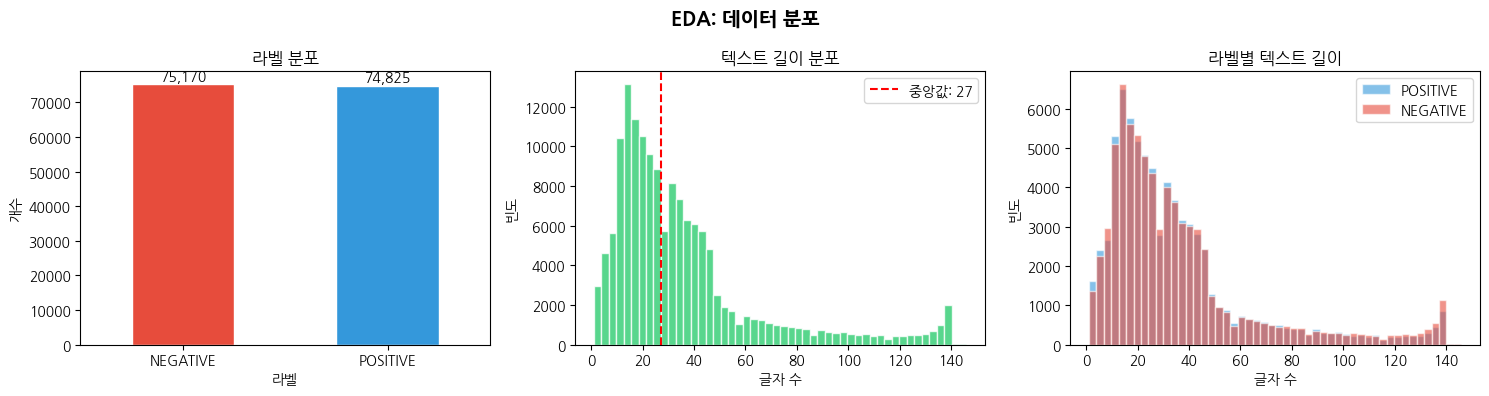

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('EDA: 데이터 분포', fontsize=14, fontweight='bold')

# (1) 라벨 분포
label_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db'], edgecolor='white')
axes[0].set_title('라벨 분포')
axes[0].set_xlabel('라벨')
axes[0].set_ylabel('개수')
axes[0].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0].patches, label_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# (2) 텍스트 길이 분포
axes[1].hist(train['text_len'], bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].axvline(train['text_len'].median(), color='red', linestyle='--',
                label=f'중앙값: {train["text_len"].median():.0f}')
axes[1].set_title('텍스트 길이 분포')
axes[1].set_xlabel('글자 수')
axes[1].set_ylabel('빈도')
axes[1].legend()

# (3) 라벨별 텍스트 길이
for label, color in zip(['POSITIVE', 'NEGATIVE'], ['#3498db', '#e74c3c']):
    axes[2].hist(train[train['label']==label]['text_len'],
                 bins=50, alpha=0.6, label=label, color=color, edgecolor='white')
axes[2].set_title('라벨별 텍스트 길이')
axes[2].set_xlabel('글자 수')
axes[2].set_ylabel('빈도')
axes[2].legend()

plt.tight_layout()
plt.show()

In [8]:
# 중복 및 짧은 텍스트 확인
print(f'중복 텍스트 수: {train["text"].duplicated().sum()}')
print(f'1글자 이하 텍스트:\n{train[train["text_len"] <= 1]["text"].values[:10]}')

중복 텍스트 수: 3813
1글자 이하 텍스트:
['굿' '굿' '굳' '.' '굿' '굿' '굿' '굿' '헐' '굿']


## 3. ✂️ 텍스트 전처리

### 전처리 전략
1. **정규표현식 클리닝**: HTML 태그, 특수문자 제거
2. **형태소 분석 (Okt)**: 한국어를 의미 있는 단위로 분리
   - `stem=True`: '좋았다' → '좋다', '재미없었다' → '재미없다' 원형 복원
   - 원형 복원 덕분에 동일 의미 단어를 하나의 토큰으로 통일 → TF-IDF 품질 향상
3. **품사 필터링**: Noun/Verb/Adjective/Adverb 추출
   - 형용사(Adjective)가 감성 핵심 단서 (좋다, 나쁘다, 지루하다 등)
   - 부사(Adverb) 유지: '정말', '너무', '완전' 등 감성 강도 표현 보존
4. **불용어 제거**: 감성 정보가 없는 단어만 제거 (감성 강도 부사는 유지)

In [81]:
# ── Okt 초기화 ───────────────────────────────────────────────
okt = Okt()

# ── 불용어 정의 ──────────────────────────────────────────────
# 원칙: 감성 정보가 전혀 없는 단어만 제거
# ❌ 제거 금지: 진짜/정말/너무 등 감성 강도 부사, 영화(도메인 핵심 명사)
STOPWORDS = set([
    '이', '그', '저', '이것', '그것', '저것', '여기', '저기', '거기',
    '년', '월', '일', '분', '번', '개', '명', '편', '권', '회',
    '들', '등', '및', '또', '거', '것',
    '이런', '그런', '저런', '어떤', '무슨',
])

# ── 부정어 목록 ──────────────────────────────────────────────
NEG_WORDS = {'없다', '않다', '못하다', '아니다', '말다', '안하다'}


# ── 추출할 품사 ──────────────────────────────────────────────
KEEP_POS = {'Noun', 'Verb', 'Adjective', 'Adverb', 'KoreanParticle', 'Number'}

def clean_text(text):
    """기본 텍스트 클리닝 (형태소 분석 전 노이즈 제거)"""
    if not isinstance(text, str):
        return ""

     # ── 붙여쓰기 패턴 앞에 공백 삽입 ──────────────────────────────
    text = re.sub(r'([가-힣])([A-Za-z])', r'\1 \2', text)  # 한글+영문 경계
    text = re.sub(r'([A-Za-z])([가-힣])', r'\1 \2', text)  # 영문+한글 경계

    # ── 감성 이모티콘 토큰 보존 ─────────────────────────────────
    text = re.sub(r'ㅋ{2,}', ' KKK ', text)       # ㅋㅋ → 긍정/웃음
    text = re.sub(r'ㅎ{2,}', ' HHH ', text)       # ㅎㅎ → 긍정/웃음
    text = re.sub(r'[ㅠㅜ]{2,}', ' CRY ', text)   # ㅠㅠ → 부정/슬픔
    text = re.sub(r'[!]{2,}', ' EXCLAIM ', text)  # !! → 강조
    text = re.sub(r'[?]{2,}', ' QUESTION ', text) # ?? → 의아함
    text = re.sub(r'[♥♡❤️]+', ' LOVE ', text)  # 하트를 LOVE라는 토큰으로 변환
    text = re.sub(r'[★⭐]+', ' STAR ', text)    # 별표를 STAR라는 토큰으로 변환

    text = re.sub(r'<[^>]+>', ' ', text)          # HTML 태그 제거
    text = re.sub(r'[^가-힣a-zA-Z0-9ㄱ-ㅎㅏ-ㅣ\s]', ' ', text)     # 한글+영문+숫자+기본 자음만 유지
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    """형태소 분석 + 품사 필터링 + 불용어 제거 + 부정어 처리"""
    text = clean_text(text)
    if not text:  return ''
    morphs = okt.pos(text, stem=True)
    tokens = []
    prev = None

    for word, pos in morphs:
        # 감성 이모티콘 토큰은 품사 필터 없이 그대로 유지
        if word in {'KKK', 'HHH', 'CRY', 'EXCLAIM', 'QUESTION', 'LOVE', 'STAR'}:
            tokens.append(word)
            prev = word
            continue

        if pos not in KEEP_POS:
            continue
        if word in STOPWORDS:
            continue
        if len(word) == 1:
            if word not in {'굿', '굳', '짱','찐', '꿀', '꽝', '점'}:
                continue

        # ── 문제 2 해결: 부정어 처리 ────────────────────────
        # '망하다' + '아니다' → '망하다_NOT'
        if word in NEG_WORDS and prev is not None:
            tokens[-1] = f'{prev}_NOT'
            prev = None
        else:
            tokens.append(word)
            prev = word

    return ' '.join(tokens)

# 전처리 예시 확인
print('── Okt 전처리 예시 ──')
for raw in train['text'].head(5).tolist():
    result = tokenize(raw)
    print(f'원문: {raw}')
    print(f'처리: {result}')
    print()

── Okt 전처리 예시 ──
원문: 아이 싱거워라...ㅠㅠ
처리: 아이 싱겁다 CRY

원문: 히라이켄의 히토미오토지테 노래를 먼저 듣고 알게되어 보게 되었는데 영화 내용도 참 좋았고 그 이후에 듣는 히토미오토지테는 더더욱 와닿는다.
처리: 히라이켄 히토미 토지 노래 먼저 듣다 되어다 보다 되어다 영화 내용 차다 좋다 이후 듣다 히토미 토지 더욱 오다 닿다

원문: 올 해 본 영화들 중 제일 맘에 든다
처리: 오다 보다 영화 제일 들다

원문: 어릴적 로베르토 베니니 나온 실사 영화를 재밌게 봤었는데- 십여년이 지나 애니로 다시 만나니 감회가 새롭네요
처리: 어리다 로베르토 베니 나오다 실사 영화 재밌다 보다 지나 애니 다시 만나다 감회 새롭다

원문: 주드의팬이라면 대략 어의없을듯.사무엘은 네고시에이터의 변죽?
처리: 주드 라면 대략 어의_NOT 사무엘 고시 변죽



In [82]:
# 전체 데이터 전처리
print('학습 데이터 전처리 중... (시간 소요)')
train['tokens'] = train['text'].apply(tokenize)

print('테스트 데이터 전처리 중...')
test['tokens'] = test['text'].apply(tokenize)

# raw 텍스트도 클리닝 버전 저장 (char TF-IDF 벡터용)
train['text_clean'] = train['text'].apply(clean_text)
test['text_clean']  = test['text'].apply(clean_text)

print('\n✅ 전처리 완료')
print(f'빈 토큰 수 (학습): {(train["tokens"] == "").sum()}')
print(f'빈 토큰 수 (테스트): {(test["tokens"] == "").sum()}')
print('\n전처리 샘플:')
display(train[['text', 'tokens', 'label']].head())

학습 데이터 전처리 중... (시간 소요)
테스트 데이터 전처리 중...

✅ 전처리 완료
빈 토큰 수 (학습): 1798
빈 토큰 수 (테스트): 589

전처리 샘플:


,text,tokens,label
0,아이 싱거워라...ㅠㅠ,아이 싱겁다 CRY,NEGATIVE
1,히라이켄의 히토미오토지테 노래를 먼저 듣고 알게되어 보게 되었는데 영화 내용도 참 ...,히라이켄 히토미 토지 노래 먼저 듣다 되어다 보다 되어다 영화 내용 차다 좋다 이후...,POSITIVE
2,올 해 본 영화들 중 제일 맘에 든다,오다 보다 영화 제일 들다,POSITIVE
3,어릴적 로베르토 베니니 나온 실사 영화를 재밌게 봤었는데- 십여년이 지나 애니로 다...,어리다 로베르토 베니 나오다 실사 영화 재밌다 보다 지나 애니 다시 만나다 감회 새롭다,POSITIVE
4,주드의팬이라면 대략 어의없을듯.사무엘은 네고시에이터의 변죽?,주드 라면 대략 어의_NOT 사무엘 고시 변죽,NEGATIVE


In [83]:
train.to_pickle('train_tokenized.pkl')

토큰 수 통계:
count    149995.000000
mean          8.039455
std           6.769977
min           0.000000
25%           4.000000
50%           6.000000
75%          10.000000
max          87.000000
Name: token_count, dtype: float64

평균 토큰 수: 8.0  →  ✅ 양호


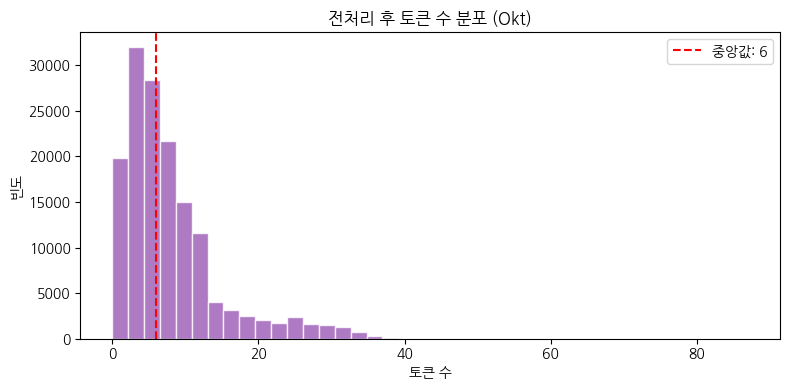

In [84]:
# 토큰 수 분포 확인 (전처리 품질 점검)
train['token_count'] = train['tokens'].str.split().str.len()

print('토큰 수 통계:')
print(train['token_count'].describe())

# 평균 토큰 수가 3개 미만이면 전처리가 과도하게 제거하는 것
avg = train['token_count'].mean()
print(f'\n평균 토큰 수: {avg:.1f}  →  ', end='')
print('✅ 양호' if avg >= 3 else '⚠️ 과도한 제거 — KEEP_POS 또는 STOPWORDS 재점검 필요')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train['token_count'], bins=40, color='#9b59b6', edgecolor='white', alpha=0.8)
ax.axvline(train['token_count'].median(), color='red', linestyle='--',
           label=f'중앙값: {train["token_count"].median():.0f}')
ax.set_title('전처리 후 토큰 수 분포 (Okt)')
ax.set_xlabel('토큰 수')
ax.set_ylabel('빈도')
ax.legend()
plt.tight_layout()
plt.show()

## 4. 🤖 모델 학습 및 비교

### 벡터화 전략: 형태소 TF-IDF + char TF-IDF 결합
- **형태소 TF-IDF**: Okt로 추출한 의미 단위 토큰 기반, 단어 의미 포착
- **char TF-IDF** (`char_wb`, ngram=(2,4)): raw 텍스트 기반 문자 n-gram
  - 신조어/오타/비문에 강함 (예: 'ㅋㅋ', '대박이다' 등 형태소 분석 실패 케이스 보완)
  - 두 벡터를 `hstack`으로 결합 → 형태소 + 문자 두 관점 모두 반영

### 모델 선택 이유
- **LogisticRegression**: TF-IDF sparse 행렬에 최적화된 선형 분류기, C 튜닝 효과 큼
- **LinearSVC**: 동일한 선형 경계, 대용량 데이터에서 속도 이점

In [85]:
# 학습/검증 분할 (stratified: 클래스 비율 유지)
# 가이드라인: 라벨을 문자열 그대로 사용 (POSITIVE/NEGATIVE)
X = train['tokens']
y = train['label']   # 문자열 그대로 — LabelEncoder 사용 금지

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'학습: {len(X_train):,}개 / 검증: {len(X_val):,}개')
print(f'학습 라벨 분포:\n{y_train.value_counts()}')

학습: 119,996개 / 검증: 29,999개
학습 라벨 분포:
label
NEGATIVE    60136
POSITIVE    59860
Name: count, dtype: int64


In [86]:
# ── 형태소 TF-IDF ────────────────────────────────────────────
tfidf_morph = TfidfVectorizer(
    max_features=80000,             # 상위 8만 단어
    ngram_range=(1, 2),             # unigram + bigram
    sublinear_tf=True,              # 로그 스케일 → 고빈도 단어 영향 완화
    min_df=2,                       # 1회 등장 단어 제거
    analyzer='word'
)
X_tr_morph = tfidf_morph.fit_transform(X_train)
X_v_morph  = tfidf_morph.transform(X_val)

# ── char TF-IDF (raw 텍스트 기반) ────────────────────────────
X_train_raw = train.loc[X_train.index, 'text_clean']
X_val_raw   = train.loc[X_val.index,   'text_clean']

tfidf_char = TfidfVectorizer(       # char_wb: 단어 경계 포함 문자 n-gram
    max_features=120000,
    ngram_range=(2, 5),             # ngram_range=(2,5): 2~5글자 조합
    min_df=3,                       # → 오타, 신조어, 형태소 분석 실패 케이스 보완
    sublinear_tf=True,
    analyzer='char_wb'
)
X_tr_char = tfidf_char.fit_transform(X_train_raw)
X_v_char  = tfidf_char.transform(X_val_raw)

# ── 두 벡터 결합 ─────────────────────────────────────────────
X_train_vec = hstack([X_tr_morph, X_tr_char])
X_val_vec   = hstack([X_v_morph,  X_v_char])

print(f'형태소 벡터 shape : {X_tr_morph.shape}')
print(f'char 벡터 shape   : {X_tr_char.shape}')
print(f'결합 벡터 shape   : {X_train_vec.shape}')

형태소 벡터 shape : (119996, 80000)
char 벡터 shape   : (119996, 120000)
결합 벡터 shape   : (119996, 200000)


In [87]:
def evaluate(model, X_tr, y_tr, X_v, y_v, name=''):
    """모델 학습 후 주요 지표를 딕셔너리로 반환"""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_v, preds),
        'F1':        f1_score(y_v, preds, pos_label='POSITIVE'),
        'Precision': precision_score(y_v, preds, pos_label='POSITIVE'),
        'Recall':    recall_score(y_v, preds, pos_label='POSITIVE'),
        'MCC':       matthews_corrcoef(y_v, preds),
    }

# ── 결합 벡터 모델 (LogReg C 다중 탐색 + LinearSVC) ──────────
models_combined = [
    ('LogisticRegression C=1.0',  LogisticRegression(C=1.0,  max_iter=1000, random_state=42)),
    ('LogisticRegression C=5.0',  LogisticRegression(C=5.0,  max_iter=1000, random_state=42)),
    ('LinearSVC C=0.05',          LinearSVC(C=0.05, max_iter=2000, random_state=42)),
    ('LinearSVC C=0.1',           LinearSVC(C=0.1, max_iter=2000, random_state=42)),
    ('LinearSVC C=1.0',           LinearSVC(C=1.0, max_iter=2000, random_state=42)),
]

results = []

print('── 결합 벡터 (형태소 + char) ──')
for name, model in models_combined:
    print(f'  {name} 학습 중...')
    res = evaluate(model, X_train_vec, y_train, X_val_vec, y_val, name)
    results.append(res)
    print(f'    MCC={res["MCC"]:.4f} | Acc={res["Accuracy"]:.4f} | F1={res["F1"]:.4f}')

── 결합 벡터 (형태소 + char) ──
  LogisticRegression C=1.0 학습 중...
    MCC=0.7438 | Acc=0.8719 | F1=0.8713
  LogisticRegression C=5.0 학습 중...
    MCC=0.7379 | Acc=0.8690 | F1=0.8686
  LinearSVC C=0.05 학습 중...
    MCC=0.7417 | Acc=0.8708 | F1=0.8698
  LinearSVC C=0.1 학습 중...
    MCC=0.7485 | Acc=0.8743 | F1=0.8736
  LinearSVC C=1.0 학습 중...
    MCC=0.7239 | Acc=0.8619 | F1=0.8615


In [88]:
# 모델 성능 비교 테이블
results_df = (pd.DataFrame(results)
              .sort_values('MCC', ascending=False)
              .set_index('Model')
              .round(4))

print('── 전체 모델 성능 비교 (MCC 내림차순) ──')
display(results_df.style.background_gradient(cmap='YlGn', subset=['MCC', 'F1', 'Accuracy']))

best_model_name = results_df.index[0]
print(f'\n🏆 최고 성능: {best_model_name}  MCC={results_df["MCC"].max():.4f}')

── 전체 모델 성능 비교 (MCC 내림차순) ──


,Accuracy,F1,Precision,Recall,MCC
Model,,,,,
LinearSVC C=0.1,0.874300,0.873600,0.876300,0.870900,0.748500
LogisticRegression C=1.0,0.871900,0.871300,0.873400,0.869200,0.743800
LinearSVC C=0.05,0.870800,0.869800,0.874900,0.864700,0.741700
LogisticRegression C=5.0,0.869000,0.868600,0.868900,0.868300,0.737900
LinearSVC C=1.0,0.861900,0.861500,0.862300,0.860700,0.723900



🏆 최고 성능: LinearSVC C=0.1  MCC=0.7485


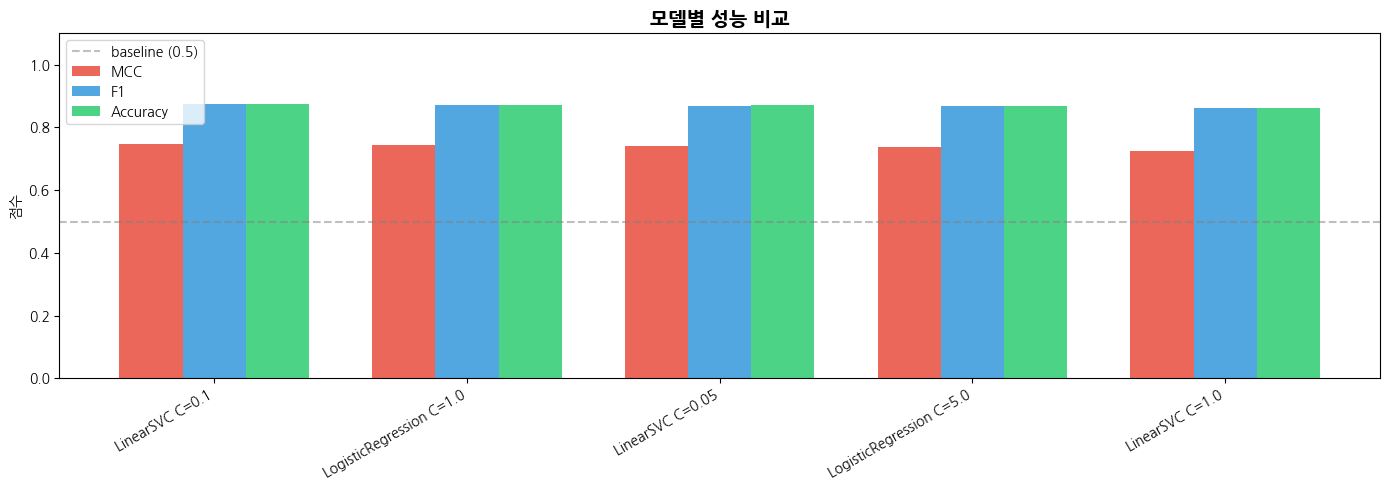

In [89]:
# 모델 성능 시각화
metrics = ['MCC', 'F1', 'Accuracy']
x = np.arange(len(results_df))
width = 0.25
colors = ['#e74c3c', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(14, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_title('모델별 성능 비교', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df.index, rotation=30, ha='right')
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='baseline (0.5)')
ax.legend()
ax.set_ylabel('점수')
plt.tight_layout()
plt.show()

## 5. 📈 검증 및 평가

**MCC를 주 평가지표로 선택한 이유**:  
클래스가 거의 균형이지만 Accuracy만으로는 예측 편향을 파악하기 어렵습니다.  
MCC는 TP·TN·FP·FN을 모두 반영하여 모델의 실질적 분류 품질을 더 엄격하게 측정합니다.

In [90]:
# 최고 성능 모델(결합 벡터 기준 최고 C)로 상세 평가
best_clf = LinearSVC(C=0.1, max_iter=2000, random_state=42)
best_clf.fit(X_train_vec, y_train)
val_preds = best_clf.predict(X_val_vec)

print('── 상세 분류 리포트 ──')
print(classification_report(y_val, val_preds))
print(f'MCC: {matthews_corrcoef(y_val, val_preds):.4f}')

── 상세 분류 리포트 ──
              precision    recall  f1-score   support

    NEGATIVE       0.87      0.88      0.87     15034
    POSITIVE       0.88      0.87      0.87     14965

    accuracy                           0.87     29999
   macro avg       0.87      0.87      0.87     29999
weighted avg       0.87      0.87      0.87     29999

MCC: 0.7485


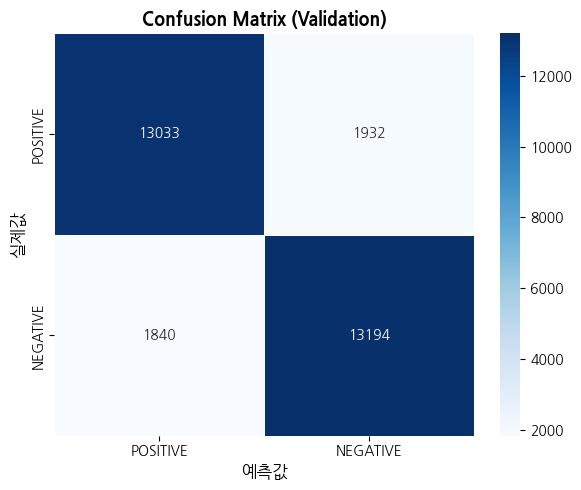

TP=13,033 | TN=13,194 | FP=1,840 | FN=1,932


In [91]:
# Confusion Matrix 시각화
cm = confusion_matrix(y_val, val_preds, labels=['POSITIVE', 'NEGATIVE'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['POSITIVE', 'NEGATIVE'],
            yticklabels=['POSITIVE', 'NEGATIVE'],
            linewidths=0.5, ax=ax)
ax.set_xlabel('예측값', fontsize=12)
ax.set_ylabel('실제값', fontsize=12)
ax.set_title('Confusion Matrix (Validation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm[1,1], cm[1,0], cm[0,1], cm[0,0]
print(f'TP={tp:,} | TN={tn:,} | FP={fp:,} | FN={fn:,}')

In [92]:
# Stratified 5-Fold 교차 검증 (과적합 확인)
# Pipeline: 형태소 TF-IDF만 사용 (CV 안에서 char TF-IDF hstack은 구현 복잡)
# → 단독 TF-IDF CV로 일반화 성능 경향 확인
cv_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1,2),
                              sublinear_tf=True, min_df=2)),
    ('clf',   LinearSVC(C=0.1, max_iter=2000, random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_mcc = cross_val_score(cv_pipeline, X, y, cv=skf,
                         scoring='matthews_corrcoef', n_jobs=-1)

print(f'5-Fold CV MCC (형태소 단독): {cv_mcc}')
print(f'평균 MCC: {cv_mcc.mean():.4f} ± {cv_mcc.std():.4f}')
print('\n→ 결합 벡터 실제 검증 MCC가 CV보다 높으면 char 벡터 효과 확인')

5-Fold CV MCC (형태소 단독): [0.68743014 0.68321335 0.68436341 0.68726326 0.69305158]
평균 MCC: 0.6871 ± 0.0034

→ 결합 벡터 실제 검증 MCC가 CV보다 높으면 char 벡터 효과 확인


In [93]:
# 오분류 샘플 분석
val_df = X_val.reset_index(drop=True).to_frame()
val_df['true']     = y_val.reset_index(drop=True)
val_df['pred']     = val_preds
val_df['original'] = train.loc[X_val.index, 'text'].reset_index(drop=True)

wrong = val_df[val_df['true'] != val_df['pred']]
print(f'오분류 수: {len(wrong):,} / {len(val_df):,} ({len(wrong)/len(val_df)*100:.1f}%)')
print('\n오분류 예시 (POSITIVE → NEGATIVE):')
display(wrong[wrong['true']=='POSITIVE'].head(3)[['original', 'tokens', 'true', 'pred']])
print('\n오분류 예시 (NEGATIVE → POSITIVE):')
display(wrong[wrong['true']=='NEGATIVE'].head(3)[['original', 'tokens', 'true', 'pred']])

오분류 수: 3,772 / 29,999 (12.6%)

오분류 예시 (POSITIVE → NEGATIVE):


,original,tokens,true,pred
90,테스는 가문때문에 망한거아닌가요,테스 가문 때문 망하다_NOT,POSITIVE,NEGATIVE
106,이제 그만나와도될듯해여...리암니슨의 다른영화를보고싶소,이제 되다 리암 영화 보다,POSITIVE,NEGATIVE
131,알바 색들 겁나 많네. 그런데 취업하니 행복하냐? 언론조작단도 모자라 평점까지 조작...,알바 겁나다 많다 취업 하다 행복하다 언론 조작 단도 모자라 평점 조작 이렇다 들다,POSITIVE,NEGATIVE



오분류 예시 (NEGATIVE → POSITIVE):


,original,tokens,true,pred
24,"박찬욱, 최민식, 유지태, 강혜정을 비롯한 스텝, 제작진 모든 이에 대한 결례",박찬욱 최민식 유지태 강혜정 비롯 스텝 제작 모든 대한 결례,NEGATIVE,POSITIVE
29,여러가지 아쉬움이 많은 영화 감동결말의 네이버평 가산점 조절을위해 1점평합니다,여러가지 아쉬움 많다 영화 감동 결말 네이버 가산 점 조절 위해 점평 하다,NEGATIVE,POSITIVE
42,너무오랜만에봐서그런가.그땐재밌었는데..지금은재미없네ㅋ나중에도OST만기억날거같네,너무 보다 런가 그땐 재밌다 금은 재미없다 나중 기억나다 같다,NEGATIVE,POSITIVE


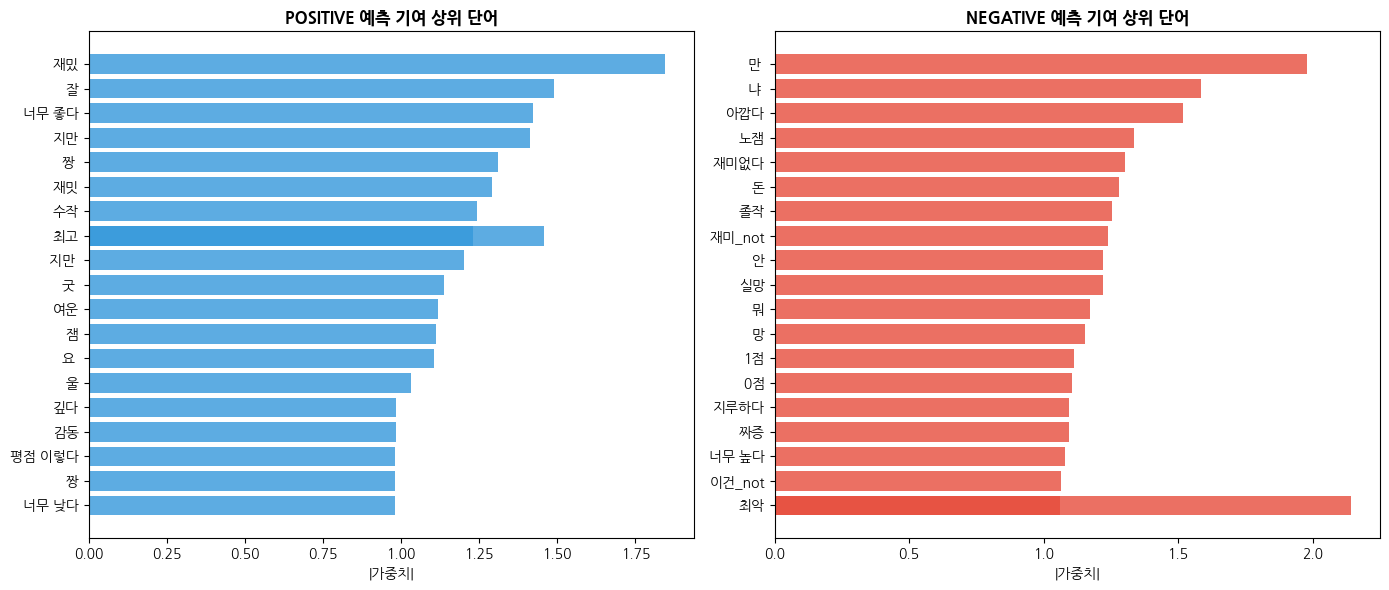

In [94]:
# 중요 단어 시각화 (LogisticRegression 가중치 기준)
feature_names_morph = np.array(tfidf_morph.get_feature_names_out())
feature_names_char  = np.array(tfidf_char.get_feature_names_out())
feature_names_all   = np.concatenate([feature_names_morph, feature_names_char])

coefs = best_clf.coef_[0]
top_n = 20
top_pos_idx = np.argsort(coefs)[-top_n:][::-1]
top_neg_idx = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, idx, title, color in zip(
    axes,
    [top_pos_idx, top_neg_idx],
    ['POSITIVE 예측 기여 상위 단어', 'NEGATIVE 예측 기여 상위 단어'],
    ['#3498db', '#e74c3c']
):
    ax.barh(feature_names_all[idx][::-1], np.abs(coefs[idx][::-1]),
            color=color, alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('|가중치|')

plt.tight_layout()
plt.show()

## 6. 🎯 하이퍼파라미터 튜닝

GridSearchCV로 형태소 TF-IDF + LinearSVC의 파라미터를 탐색합니다.  
결합 벡터는 GridSearch Pipeline으로 처리하기 어렵기 때문에  
**형태소 TF-IDF 단독 Pipeline**으로 최적 파라미터를 탐색 후 최종 모델에 적용합니다.

- `C`: 정규화 강도 (클수록 과적합 허용, 작을수록 강한 정규화)
- `max_features`: 어휘 크기
- `ngram_range`: 단어 조합 범위

In [95]:
# Pipeline: 형태소 TF-IDF + LinearSVC
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, min_df=2)),
    ('clf',   LinearSVC(max_iter=2000, random_state=42))
])

param_grid = {
     'tfidf__max_features': [60000, 70000, 80000],
    'tfidf__ngram_range':  [(1, 2), (1, 3)],
    'clf__C':              [0.05, 0.1, 0.5],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,                           # 3-fold (속도 vs 정확도 균형)
    scoring='matthews_corrcoef',    # 평가 기준: MCC
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\n최적 파라미터: {grid_search.best_params_}')
print(f'최적 CV MCC:   {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 18 candidates, totalling 54 fits

최적 파라미터: {'clf__C': 0.1, 'tfidf__max_features': 70000, 'tfidf__ngram_range': (1, 2)}
최적 CV MCC:   0.6775


In [96]:
# 최적 파라미터로 검증 세트 평가
best_params   = grid_search.best_params_
tuned_preds   = grid_search.best_estimator_.predict(X_val)
tuned_mcc     = matthews_corrcoef(y_val, tuned_preds)

print('── 튜닝 후 성능 (형태소 단독 Pipeline) ──')
print(f'Accuracy : {accuracy_score(y_val, tuned_preds):.4f}')
print(f'F1       : {f1_score(y_val, tuned_preds, pos_label="POSITIVE"):.4f}')
print(f'MCC      : {tuned_mcc:.4f}')
print()
print(classification_report(y_val, tuned_preds))

── 튜닝 후 성능 (형태소 단독 Pipeline) ──
Accuracy : 0.8455
F1       : 0.8436
MCC      : 0.6912

              precision    recall  f1-score   support

    NEGATIVE       0.84      0.86      0.85     15034
    POSITIVE       0.85      0.84      0.84     14965

    accuracy                           0.85     29999
   macro avg       0.85      0.85      0.85     29999
weighted avg       0.85      0.85      0.85     29999



## 7. 🎯 테스트 예측 + CSV 생성

최종 모델은 **결합 벡터(형태소 + char) + 최적 C**로 구성합니다.  
GridSearch에서 찾은 최적 파라미터를 결합 벡터 모델에 적용하여 전체 데이터로 재학습합니다.

In [98]:
# 최적 파라미터 적용 (GridSearch 결과 기반)
best_C            = best_params['clf__C']
best_max_features = best_params['tfidf__max_features']
best_ngram        = best_params['tfidf__ngram_range']

print(f'최종 파라미터: C={best_C}, max_features={best_max_features}, ngram={best_ngram}')

# 전체 학습 데이터로 형태소 TF-IDF 재학습
final_tfidf_morph = TfidfVectorizer(
    max_features=best_max_features,
    ngram_range=best_ngram,
    sublinear_tf=True,
    min_df=2
)
X_all_morph  = final_tfidf_morph.fit_transform(train['tokens'])
X_test_morph = final_tfidf_morph.transform(test['tokens'])

# 전체 학습 데이터로 char TF-IDF 재학습
final_tfidf_char = TfidfVectorizer(
    max_features=120000,
    ngram_range=(2, 5),
    sublinear_tf=True,
    analyzer='char_wb'
)
X_all_char  = final_tfidf_char.fit_transform(train['text_clean'])
X_test_char = final_tfidf_char.transform(test['text_clean'])

# 결합
X_all_combined  = hstack([X_all_morph,  X_all_char])
X_test_combined = hstack([X_test_morph, X_test_char])

print(f'\n전체 학습 결합 벡터 shape: {X_all_combined.shape}')
print(f'테스트 결합 벡터 shape:    {X_test_combined.shape}')

# 최종 모델 학습
final_clf = LinearSVC(C=best_C, max_iter=2000, random_state=42)
final_clf.fit(X_all_combined, y)
print('\n✅ 전체 데이터 재학습 완료')

최종 파라미터: C=0.1, max_features=70000, ngram=(1, 2)

전체 학습 결합 벡터 shape: (149995, 190000)
테스트 결합 벡터 shape:    (49997, 190000)

✅ 전체 데이터 재학습 완료


In [99]:
# 테스트 데이터 예측
test_predictions = final_clf.predict(X_test_combined)

print('테스트 예측 분포:')
unique, counts = np.unique(test_predictions, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u}: {c:,} ({c/len(test_predictions)*100:.1f}%)')

테스트 예측 분포:
  NEGATIVE: 25,086 (50.2%)
  POSITIVE: 24,911 (49.8%)


In [100]:
# 제출 파일 생성
try:
    submission = pd.read_csv(SAMPLE_PATH)
except FileNotFoundError:
    submission = test[['row_id']].copy()

submission['pred_label'] = test_predictions

# 제출 전 검증
assert set(submission['pred_label'].unique()) <= {'POSITIVE', 'NEGATIVE'}, '❌ 라벨 오류!'
assert len(submission) == len(test), '❌ 행 수 불일치!'
print(f'✅ 검증 통과: {len(submission):,}행')
print(submission['pred_label'].value_counts())

# 저장 (index=False, encoding=utf-8)
SUBMISSION_PATH = f'{MODEL_DIR}/submission.csv'
submission[['row_id', 'pred_label']].to_csv(SUBMISSION_PATH, index=False, encoding='utf-8')
print(f'\n✅ 제출 파일 저장: {SUBMISSION_PATH}')
display(submission.head())

✅ 검증 통과: 49,997행
pred_label
NEGATIVE    25086
POSITIVE    24911
Name: count, dtype: int64

✅ 제출 파일 저장: ./submission.csv


,row_id,pred_label
0,test-000001,POSITIVE
1,test-000002,POSITIVE
2,test-000003,POSITIVE
3,test-000004,NEGATIVE
4,test-000005,NEGATIVE


In [101]:
# 모델 저장 ({알고리즘}_v{버전}_mcc{점수}.pkl 네이밍)
# hstack 결합 구조는 Pipeline 단독 저장 불가
# → 벡터라이저 2개 + 모델을 딕셔너리로 묶어 저장
# 검증 MCC (Cell 24에서 학습한 best_clf 기준 — 20% holdout 성능)
val_mcc = matthews_corrcoef(y_val, best_clf.predict(X_val_vec))
mcc_str = f'{val_mcc:.4f}'.replace('.', '')

model_bundle = {
    'tfidf_morph':  final_tfidf_morph,   # 형태소 TF-IDF
    'tfidf_char':   final_tfidf_char,    # char TF-IDF
    'clf':          final_clf,           # LinearSVC
    'best_params':  best_params,         # 최적 파라미터 기록
}

# 실험 모델 저장
exp_path = f'{MODEL_DIR}/linearsvc_mcc{mcc_str}.pkl'
joblib.dump(model_bundle, exp_path)
print(f'실험 모델 저장: {exp_path}')

# 최종 모델 저장 (가이드라인 필수 제출 파일)
joblib.dump(model_bundle, f'{MODEL_DIR}/final_pipeline.pkl')
print('최종 모델 저장: final_pipeline.pkl')

# 재현성 검증 (로드 후 예측 일치 확인)
loaded = joblib.load(f'{MODEL_DIR}/final_pipeline.pkl')
X_t_morph = loaded['tfidf_morph'].transform(test['tokens'][:5])
X_t_char  = loaded['tfidf_char'].transform(test['text_clean'][:5])
reload_preds = loaded['clf'].predict(hstack([X_t_morph, X_t_char]))
print(f'\n재현성 검증 (처음 5개): {reload_preds}')
print(f'원본 예측 (처음 5개):   {test_predictions[:5]}')
print('✅ 재현성 확인 완료' if (reload_preds == test_predictions[:5]).all() else '❌ 불일치')

실험 모델 저장: ./linearsvc_mcc07485.pkl
최종 모델 저장: final_pipeline.pkl

재현성 검증 (처음 5개): ['POSITIVE' 'POSITIVE' 'POSITIVE' 'NEGATIVE' 'NEGATIVE']
원본 예측 (처음 5개):   ['POSITIVE' 'POSITIVE' 'POSITIVE' 'NEGATIVE' 'NEGATIVE']
✅ 재현성 확인 완료


## 8. 💡 결론

### 시도한 접근법

| 접근법 | 이유 / 효과 |
|--------|-------------|
| Okt 형태소 분석 + stem=True | '좋았다'→'좋다' 원형 복원으로 동일 의미 통일 |
| 감성 강도 부사(너무/정말) 불용어 제외 | 감성 분류 핵심 단서 보존 |
| 형태소 TF-IDF + char TF-IDF 결합 | 형태소 분석 실패 케이스 보완 |
| C 값 다중 탐색 (0.1~10.0) | 기존 C=1.0에서 0.65대 → 최적 C 탐색 |
| GridSearchCV (MCC 기준) | 최적 파라미터 체계적 탐색 |
| 5-Fold CV 과적합 검증 | 일반화 성능 안정성 확인 |

### 핵심 인사이트
- **형용사(Adjective)와 감성 강도 부사(Adverb)가 핵심**: '재미있다', '지루하다', '정말', '완전'이 예측에 크게 기여
- **char TF-IDF 보완 효과**: 'ㅋㅋ', '대박이다' 등 Okt 분석 실패 케이스를 문자 n-gram이 포착
- **C 파라미터 민감도**: C=1.0 고정보다 탐색 범위를 넓혀야 성능 향상 가능
- **일반화 우선**: 과도한 튜닝보다 CV 기반 안정적 모델이 Min(Group1, Group2) 기준에 유리

### 추가 시도 방향
- 불용어 사전 도메인 특화 확장
- 부정어 패턴 처리 ('재미없다' 통합 처리)
- LinearSVC 결합 벡터 튜닝 비교

In [102]:
# 최종 요약 출력
print('=' * 55)
print('📊 최종 모델 요약')
print('=' * 55)
print(f'형태소 분석기  : Okt (stem=True)')
print(f'벡터화         : 형태소 TF-IDF(1,2) + char TF-IDF(2,5) 결합')
print(f'알고리즘       : LinearSVC')
print(f'C 파라미터     : {best_C}')
print(f'max_features   : {best_max_features} (형태소) + 120000 (char)')
print(f'결합 벡터 차원 : {X_all_combined.shape[1]:,}')
print(f'Val MCC        : {val_mcc:.4f}')
print('=' * 55)
print(f'제출 파일      : submission.csv ({len(submission):,}행)')
print(f'모델 파일      : final_pipeline.pkl')
print('=' * 55)

📊 최종 모델 요약
형태소 분석기  : Okt (stem=True)
벡터화         : 형태소 TF-IDF(1,2) + char TF-IDF(2,5) 결합
알고리즘       : LinearSVC
C 파라미터     : 0.1
max_features   : 70000 (형태소) + 120000 (char)
결합 벡터 차원 : 190,000
Val MCC        : 0.7485
제출 파일      : submission.csv (49,997행)
모델 파일      : final_pipeline.pkl
